In [14]:
#Imports and data
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)
print("features:", len(feature_cols))

train: (8644, 7) (8644,)
test:  (2162, 7) (2162,)
features: 7


In [15]:
# Imports
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [16]:
# Helper Function for Evaluation
def evaluate_svm(model_name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    print(model_name)
    print("Accuracy:", accuracy)
    print("F1:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Training Time:", train_time)
    print("Prediction Time:", pred_time)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Training Time": train_time,
        "Prediction Time": pred_time,
        "Predictions": y_pred,
        "Best Estimator": model
    }

In [17]:
# SVM Model #1: Baseline Model
param_grid = {
    "C": [0.1, 1, 10, 100]
}

baseline_grid = GridSearchCV(
    LinearSVC(
        loss="squared_hinge",
        max_iter=10000,
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

baseline_result = evaluate_svm(
    "SVM Baseline",
    baseline_grid,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Best params:", baseline_grid.best_params_)

SVM Baseline
Accuracy: 0.37650323774283073
F1: 0.31392766275958134
Precision: 0.2940358691390535
Recall: 0.37650323774283073
Training Time: 2.8402488231658936
Prediction Time: 0.0007269382476806641

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.51      0.44       764
           1       0.36      0.56      0.44       745
           2       0.50      0.05      0.09       135
           3       0.00      0.00      0.00       466
           4       0.00      0.00      0.00        52

    accuracy                           0.38      2162
   macro avg       0.25      0.22      0.20      2162
weighted avg       0.29      0.38      0.31      2162

Best params: {'C': 1}


In [18]:
# SVM Model #2: Balanced Class Weights
balanced_grid = GridSearchCV(
    LinearSVC(
        loss="squared_hinge",
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

balanced_result = evaluate_svm(
    "SVM Balanced",
    balanced_grid,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Best params:", balanced_grid.best_params_)

SVM Balanced
Accuracy: 0.3547641073080481
F1: 0.30606549572283803
Precision: 0.3092072170452037
Recall: 0.3547641073080481
Training Time: 0.28034400939941406
Prediction Time: 0.0007140636444091797

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.43      0.40       764
           1       0.36      0.56      0.44       745
           2       0.17      0.05      0.08       135
           3       0.21      0.03      0.05       466
           4       0.00      0.00      0.00        52

    accuracy                           0.35      2162
   macro avg       0.22      0.21      0.19      2162
weighted avg       0.31      0.35      0.31      2162

Best params: {'C': 0.1}


In [19]:
# Results Table
svm_results = pd.DataFrame([
    {
        "SVM Model": "Baseline SVM",
        "Best C": baseline_grid.best_params_["C"],
        "Accuracy": baseline_result["Accuracy"],
        "Weighted F1": baseline_result["F1"],
        "Training Time": baseline_result["Training Time"],
        "Prediction Time": baseline_result["Prediction Time"]
    },
    {
        "SVM Model": "Balanced SVM",
        "Best C": balanced_grid.best_params_["C"],
        "Accuracy": balanced_result["Accuracy"],
        "Weighted F1": balanced_result["F1"],
        "Training Time": balanced_result["Training Time"],
        "Prediction Time": balanced_result["Prediction Time"]
    }
])

svm_results

,SVM Model,Best C,Accuracy,Weighted F1,Training Time,Prediction Time
0,Baseline SVM,1.0,0.376503,0.313928,2.840249,0.000727
1,Balanced SVM,0.1,0.354764,0.306065,0.280344,0.000714


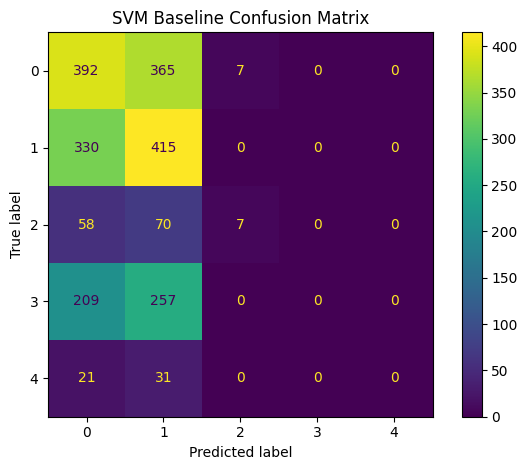

In [20]:
# Confusion Matrix
best_result = baseline_result if baseline_result["F1"] >= balanced_result["F1"] else balanced_result

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_result["Predictions"]
)

plt.title(best_result["Model"] + " Confusion Matrix")
plt.tight_layout()
plt.show()